<a href="https://colab.research.google.com/github/Dana-Mutairi/assignment-2-object-detection/blob/main/Assignment_2_Object_Detection_and_Descriptive_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Object Detection and Descriptive Summary

## Objective

This project implements an object-detection pipeline using Ultralytics YOLO26. A custom basketball image is processed to extract object classes, confidence scores, and bounding-box coordinates. A custom confidence threshold is applied, bounding boxes and labels are drawn manually using OpenCV, and a natural-language summary of the detected scene is generated programmatically.

## 1. Environment Setup

Ultralytics is used to run the YOLO26 model. NumPy and PIL are used for image representation, OpenCV is used to draw bounding boxes and labels, and Matplotlib is used to display the final result.

In [4]:
!pip install -q ultralytics

In [5]:
from ultralytics import YOLO
from PIL import Image
from collections import Counter
import numpy as np
import cv2
import matplotlib.pyplot as plt

## 2. Loading the Custom Image

A custom image showing a basketball player holding a basketball was obtained from the internet and uploaded to the Google Colab environment. The image is loaded using PIL and converted to RGB format.


Image size (width, height): (437, 702)
Array shape: (702, 437, 3)
Data type: uint8


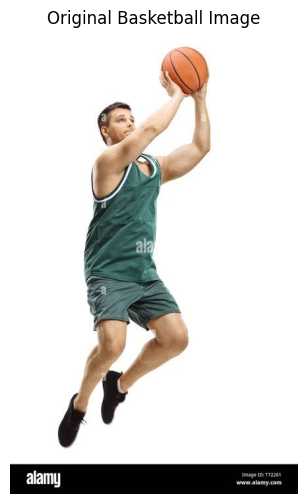

In [6]:
image_path = "basketball_player.jpg"

image_pil = Image.open(image_path).convert("RGB")
image = np.array(image_pil)

print("Image size (width, height):", image_pil.size)
print("Array shape:", image.shape)
print("Data type:", image.dtype)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.title("Original Basketball Image")
plt.axis("off")
plt.show()

## 3. YOLO26 Object Detection

The pretrained YOLO26 nano model is loaded and used to run inference on the custom image. A low model-level confidence value is used so that confidence filtering can be implemented manually afterward.

In [7]:
model = YOLO("yolo26n.pt")

results = model.predict(
    source=image_path,
    conf=0.01
)

result = results[0]

print("Number of raw detections:", len(result.boxes))
print("Detection tensor shape:", result.boxes.data.shape)


image 1/1 /content/basketball_player.jpg: 640x416 1 person, 1 frisbee, 1 sports ball, 424.2ms
Speed: 18.6ms preprocess, 424.2ms inference, 7.9ms postprocess per image at shape (1, 3, 640, 416)
Number of raw detections: 3
Detection tensor shape: torch.Size([3, 6])


## 4. Custom Confidence Threshold

A confidence threshold is applied manually. Only detections whose confidence score is equal to or greater than the selected threshold are retained and displayed.

In [8]:
confidence_threshold = 0.35

print("Custom confidence threshold:", confidence_threshold)


Custom confidence threshold: 0.35


## 5. Manual Bounding-Box Drawing

The coordinates, confidence score, and class ID of each detection are extracted directly from the YOLO result. Detections below the custom threshold are ignored. OpenCV is then used to draw each bounding box and write its class label and confidence score manually.

In [9]:
# Create a copy so the original image remains unchanged
annotated_image = image.copy()

# Store accepted class labels for the descriptive summary
detected_labels = []

# Examine every detection returned by YOLO
for box in result.boxes:

    # Extract coordinates
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    # Extract confidence and class ID
    confidence = float(box.conf[0])
    class_id = int(box.cls[0])

    # Apply custom confidence filtering
    if confidence < confidence_threshold:
        continue

    # Convert class ID to class name
    class_name = result.names[class_id]
    detected_labels.append(class_name)

    # Convert coordinates to integers
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # Create label text
    label = f"{class_name}: {confidence:.2f}"

    # Draw the bounding box manually
    cv2.rectangle(
        annotated_image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        3
    )

    # Keep the text inside the image
    text_y = max(y1 - 10, 20)

    # Write class and confidence above the object
    cv2.putText(
        annotated_image,
        label,
        (x1, text_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

    # Print the extracted information
    print(
        f"Class: {class_name}, "
        f"Confidence: {confidence:.2f}, "
        f"Box: ({x1}, {y1}, {x2}, {y2})"
    )

print("Accepted detections:", len(detected_labels))

Class: person, Confidence: 0.95, Box: (67, 65, 306, 638)
Class: sports ball, Confidence: 0.90, Box: (227, 21, 301, 95)
Accepted detections: 2


## 6. Programmatic Descriptive Summary

The accepted class labels are counted using Python. A natural-language description is generated based on the objects detected in the image.


In [10]:
# Count repeated detected classes
object_counts = Counter(detected_labels)

if not object_counts:
    summary = (
        f"No objects met the confidence threshold of "
        f"{confidence_threshold:.2f}."
    )

else:
    object_phrases = []

    for class_name, count in object_counts.items():
        if count == 1:
            object_phrases.append(f"1 {class_name}")
        else:
            object_phrases.append(f"{count} {class_name} objects")

    if len(object_phrases) == 1:
        objects_text = object_phrases[0]
    else:
        objects_text = (
            ", ".join(object_phrases[:-1])
            + " and "
            + object_phrases[-1]
        )

    summary = (
        f"The image contains {objects_text}. "
        f"All displayed detections have confidence scores of at least "
        f"{confidence_threshold:.2f}."
    )

    # Add a scene-specific interpretation
    if "person" in object_counts and "sports ball" in object_counts:
        summary += (
            " The detected person and sports ball indicate a basketball scene."
        )
    elif "person" in object_counts:
        summary += " The main subject of the scene is a person."

print("Generated summary:")
print(summary)

Generated summary:
The image contains 1 person and 1 sports ball. All displayed detections have confidence scores of at least 0.35. The detected person and sports ball indicate a basketball scene.


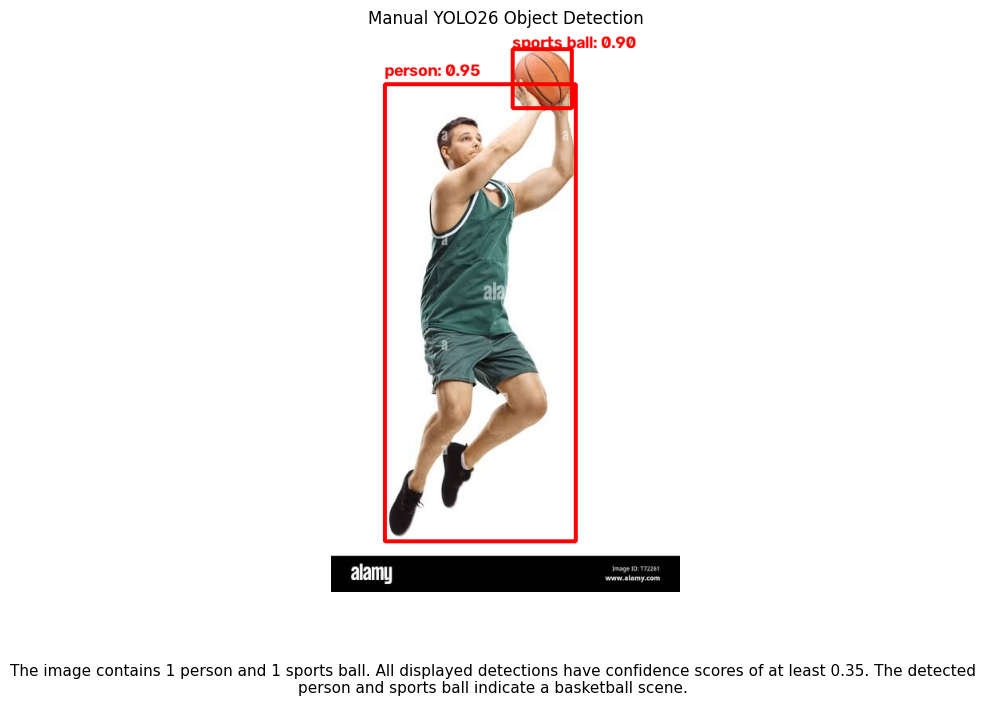

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(annotated_image)
ax.set_title("Manual YOLO26 Object Detection")
ax.axis("off")

# Leave space beneath the image
plt.subplots_adjust(bottom=0.18)

# Place the generated description below the image
fig.text(
    0.5,
    0.05,
    summary,
    ha="center",
    va="bottom",
    wrap=True,
    fontsize=11
)

plt.show()

## 7. Saving the Result

The manually annotated image is saved as a PNG file for documentation and future use.

In [12]:
final_image = Image.fromarray(annotated_image)
final_image.save("basketball_detection_result.png")

print("Final image saved as basketball_detection_result.png")

Final image saved as basketball_detection_result.png


## 8. Conclusion

This project implemented a complete object-detection pipeline using a pretrained YOLO26 model. Detection coordinates, class IDs, class names, and confidence scores were extracted directly from the model output. A custom confidence threshold was applied manually, and the accepted bounding boxes and labels were drawn using OpenCV without using YOLO's built-in plotting function. Finally, the detected classes were counted and converted into a natural-language description displayed below the annotated image.